# Fig. 1 layout lab
Loads only the cached grids in `paper_figs/fig1/data/` (run `python fig1_bundle.py` to refresh).
No torch, no GPU: every figure here is a re-render. Edit `ROWS`, `METHODS`, `STYLE` and re-run.

Views: `straight` (10-seed flat sheet), `curved` (10-seed Bezier sheet), `plane` (wide plane
through seeds 0, 1, 2; `plane_t345`, `plane_t678` through 3, 4, 5 and 6, 7, 8), `hex19` (19-seed flat sheet; no M3f). Loss: `"own"` (each method's
training loss) or `"merit"` (obj + 1e5 * L1 violation; after FS for M3f).

In [15]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
from numpy.lib.stride_tricks import sliding_window_view

from fig1_common import own_loss

DATA = "paper_figs/fig1/data"
VIEWS = {v: dict(np.load(f"{DATA}/{v}.npz")) for v in ["straight", "curved", "plane", "plane_t345", "plane_t678", "hex19"]
         if os.path.exists(f"{DATA}/{v}.npz")}
for v, d in VIEWS.items():
    print(v, sorted({k.split("/")[0] for k in d}))

LABEL = {"M1": r"SL, soft penalty, $\rho = 10^1$", "M2": r"SL, soft penalty, $\rho = 10^5$",
         "M3f": "SL, hard FS", "M4": r"SSL, soft penalty, $\rho = 10^1$"}

straight ['M1', 'M2', 'M3f', 'M4']
curved ['M1', 'M2', 'M3f', 'M4']
plane ['M1', 'M2', 'M3f', 'M4']
hex19 ['M1', 'M2', 'M4']


In [16]:
def loss(view, m, kind="own"):
    d = VIEWS[view]
    c = {k.split("/", 1)[1]: d[k].astype(np.float64) for k in d if k.startswith(m + "/")}
    if kind == "own":
        return own_loss(m, c)
    if kind == "merit":
        return c["obj_fs"] + 1e5 * c["viol_l1_fs"] if m == "M3f" else c["obj"] + 1e5 * c["viol_l1"]
    raise ValueError(kind)


def local_minima(Z, k=2):
    """Grid points lower than every other point in their (2k+1)^2 window; off-sheet = +inf."""
    Zs = np.where(np.isfinite(Z), Z, np.inf)
    w = sliding_window_view(np.pad(Zs, k, constant_values=np.inf), (2 * k + 1, 2 * k + 1))
    others = np.delete(w.reshape(*Zs.shape, -1), (2 * k + 1) ** 2 // 2, axis=-1)
    is_min = np.isfinite(Zs) & (Zs[..., None] < others).all(-1)
    is_min[:k, :] = is_min[-k:, :] = is_min[:, :k] = is_min[:, -k:] = False
    return np.nonzero(is_min)


def surface(view, m, kind="own", cap=3.0):
    """log10(L / L_best_seed), clipped to [0, cap]; seed grid indices; local minima."""
    d = VIEWS[view]
    xs, ys, pts = d[f"{m}/xs"], d[f"{m}/ys"], d[f"{m}/points"]
    Z = loss(view, m, kind)
    inside = np.isfinite(Z)
    if np.nanmin(Z) <= 0:  # SSL loss can be negative
        Z = Z - np.nanmin(Z) + 1.0
    Jg, Ig = np.nonzero(inside)  # nearest on-sheet grid point to each seed
    idx = [(int(Jg[k]), int(Ig[k])) for k in (np.argmin((xs[Ig] - p[0]) ** 2 + (ys[Jg] - p[1]) ** 2) for p in pts)]
    T = np.log10(Z / min(Z[k] for k in idx))
    jm, im = local_minima(Z)
    return dict(xs=xs, ys=ys, T=T, Tc=np.where(inside, np.clip(T, 0, cap), np.nan), idx=idx, minima=(jm, im))

In [17]:
STYLE = dict(cap=3.0, elev=42, azim=-65, stride=2, mesh=True, minima=True, seed_labels=False,
             label_size=16, cmap="viridis")


def draw3d(ax, s, st):
    X, Y = np.meshgrid(s["xs"], s["ys"])
    kw = dict(linewidth=0.02, edgecolor="k") if st["mesh"] else dict(linewidth=0, antialiased=False)
    ax.plot_surface(X, Y, s["Tc"], cmap=st["cmap"], vmin=0, vmax=st["cap"], rstride=st["stride"],
                    cstride=st["stride"], alpha=0.92, **kw)
    if st["minima"]:
        jm, im = s["minima"]
        ax.scatter(s["xs"][im], s["ys"][jm], s["Tc"][jm, im], color="w", edgecolors="k", s=26, depthshade=False)
    for j, i in s["idx"]:
        ax.scatter([s["xs"][i]], [s["ys"][j]], [s["Tc"][j, i]], color="r", edgecolors="k", s=50, depthshade=False)
    ax.set_zlim(0, st["cap"]), ax.set_zticks(range(int(st["cap"]) + 1)), ax.view_init(elev=st["elev"], azim=st["azim"])


def draw2d(ax, s, st):
    X, Y = np.meshgrid(s["xs"], s["ys"])
    cs = ax.contourf(X, Y, np.ma.masked_invalid(s["Tc"]), levels=np.linspace(0, st["cap"], 31), cmap=st["cmap"])
    if st["minima"]:
        jm, im = s["minima"]
        ax.plot(s["xs"][im], s["ys"][jm], "o", mfc="w", mec="k", ms=5)
    for n, (j, i) in enumerate(s["idx"]):
        ax.plot(s["xs"][i], s["ys"][j], "o", mfc="r", mec="k", ms=8)
        if st["seed_labels"]:
            ax.annotate(f"s{n}", (s["xs"][i], s["ys"][j]), textcoords="offset points", xytext=(4, 4), color="w")
    ax.set_aspect("equal"), ax.set_axis_off()
    return cs


def figure(rows, methods, style=None, path=None, col_w=6.5, row_h=5.5, label_row=None):
    """rows: list of (view, "3d" | "2d", loss kind). Method labels go on label_row (default: first 2D row)."""
    st = {**STYLE, **(style or {})}
    fig = plt.figure(figsize=(col_w * len(methods), row_h * len(rows)))
    gs = fig.add_gridspec(len(rows), len(methods), hspace=0.08, wspace=0.05)
    if label_row is None:
        label_row = next((r for r, row in enumerate(rows) if row[1] == "2d"), 0)
    cs, axes2d = None, []
    for r, (view, kind3, lk) in enumerate(rows):
        for c, m in enumerate(methods):
            if f"{m}/xs" not in VIEWS.get(view, {}):
                continue
            s = surface(view, m, lk, st["cap"])
            if kind3 == "3d":
                ax = fig.add_subplot(gs[r, c], projection="3d")
                draw3d(ax, s, st)
            else:
                ax = fig.add_subplot(gs[r, c])
                cs = draw2d(ax, s, st)
                axes2d.append(ax)
            if r == label_row:
                ax.legend(handles=[Line2D([], [], ls="", label=LABEL[m])], loc="upper center",
                          bbox_to_anchor=(0.5, 1.13), handlelength=0, handletextpad=0,
                          fontsize=st["label_size"], frameon=True)
    keys = [Line2D([], [], ls="", marker="o", mfc="r", mec="k", ms=10, label="trained models")]
    if st["minima"]:
        keys.append(Line2D([], [], ls="", marker="o", mfc="w", mec="k", ms=7, label="local minima"))
    fig.legend(handles=keys, loc="lower center", ncol=len(keys), bbox_to_anchor=(0.45, 0.0), fontsize=14, frameon=False)
    if cs is not None:
        fig.colorbar(cs, ax=axes2d, shrink=0.8, pad=0.01, ticks=range(int(st["cap"]) + 1),
                     label=r"$\log_{10}(L / L_{\mathrm{best}})$, held-out")
    if path:
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print(path)
    return fig

## Examples (edit freely)

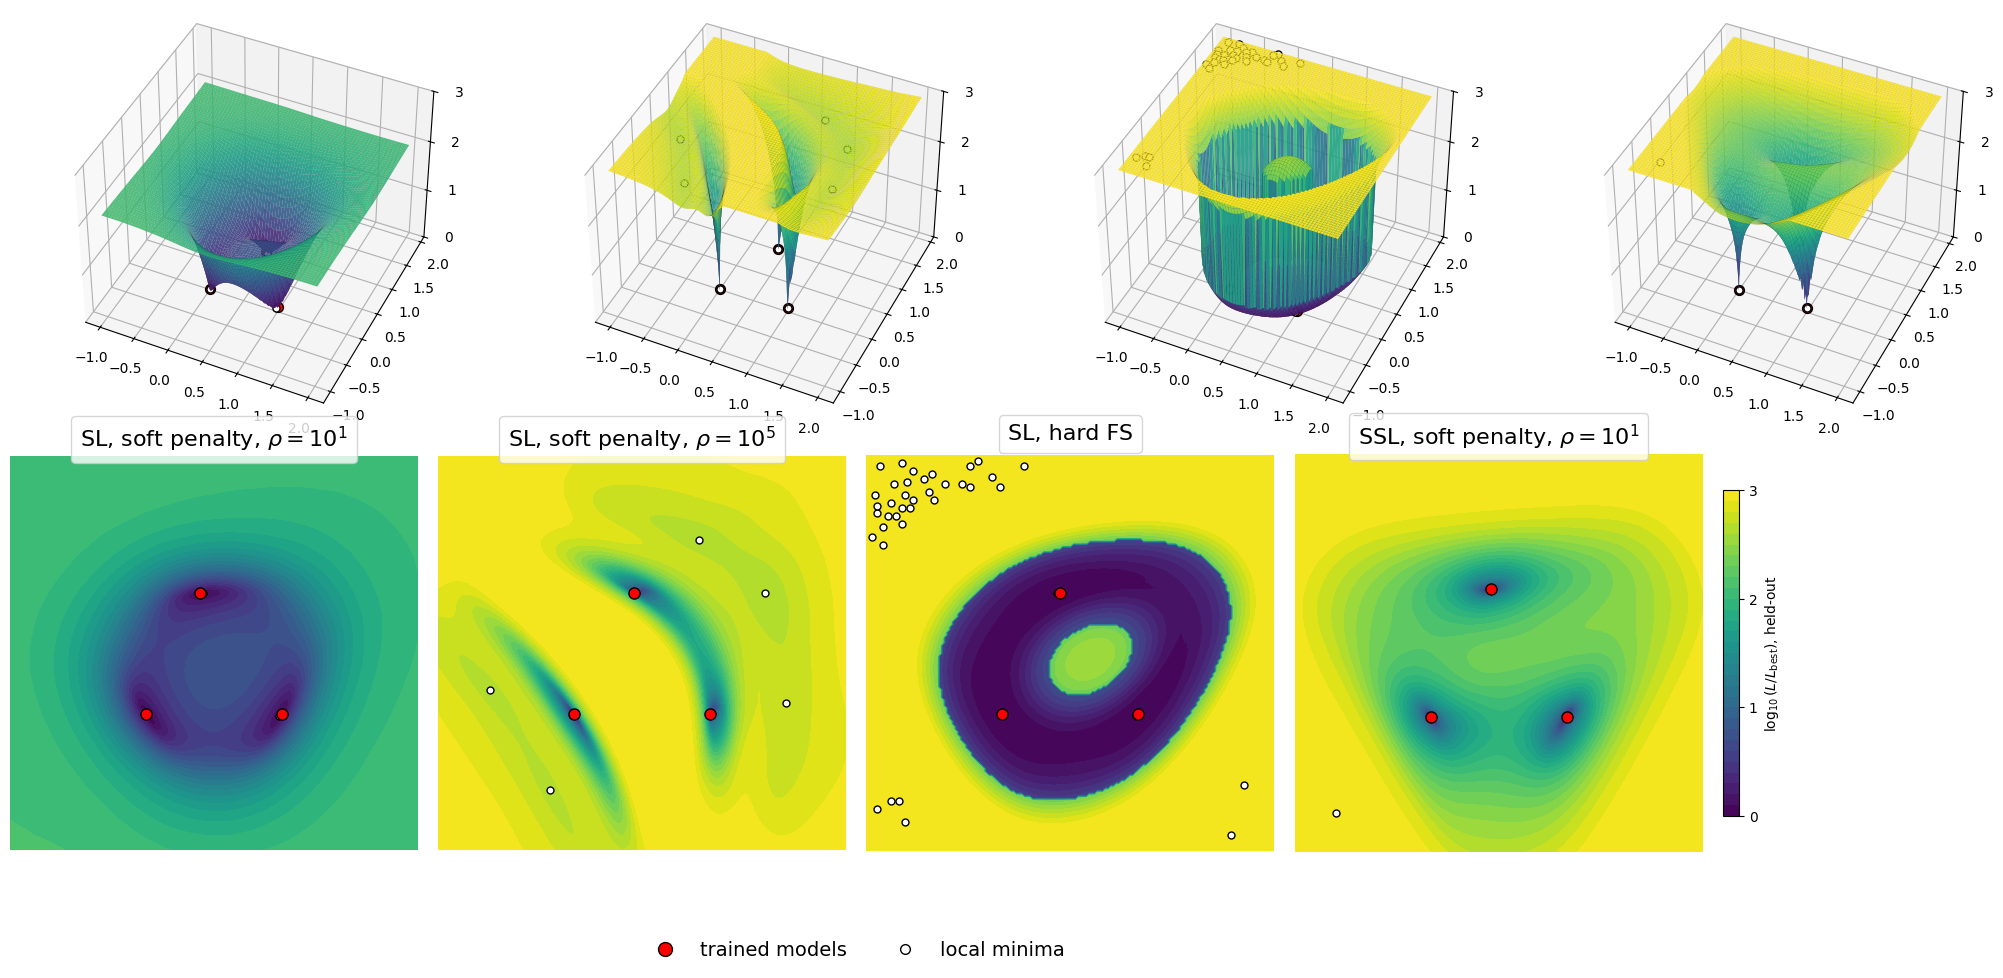

In [ ]:
METHODS = ["M1", "M2", "M3f", "M4"]

# Many-minima style: wide plane through 3 seeds
figure([("plane", "3d", "own"), ("plane", "2d", "own")], METHODS)

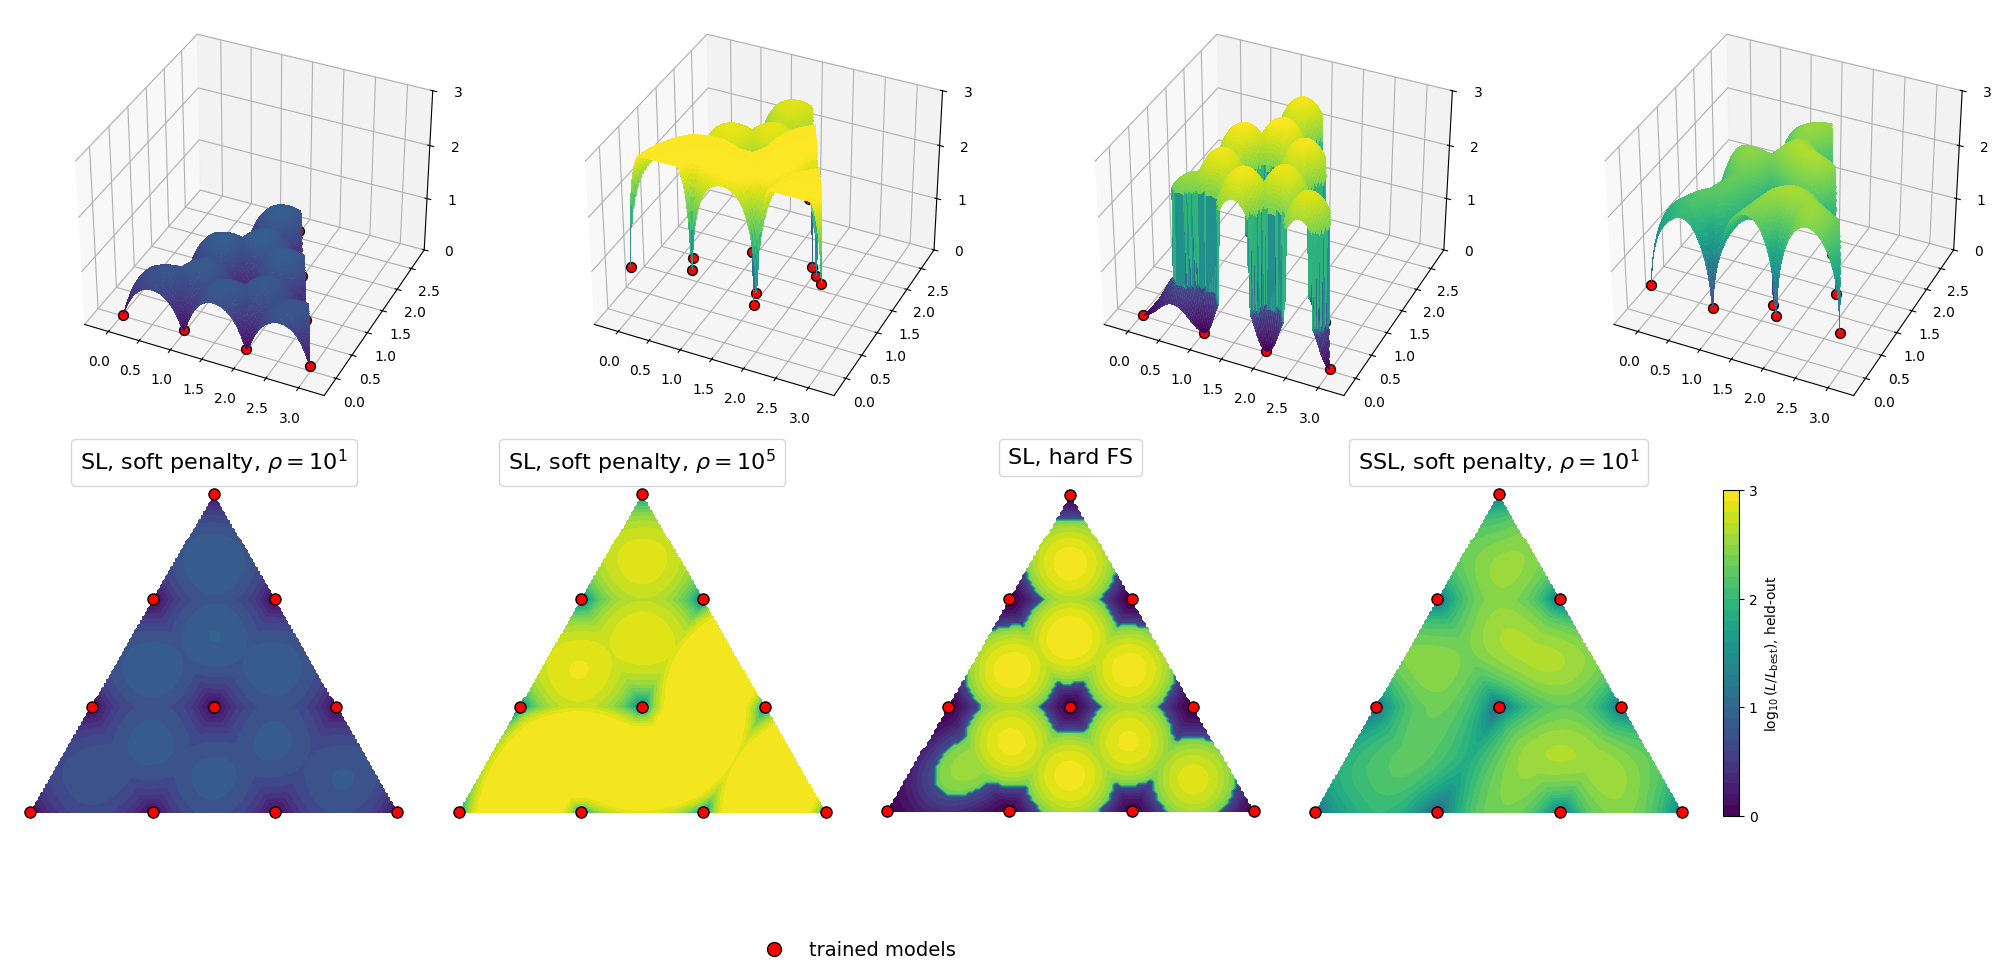

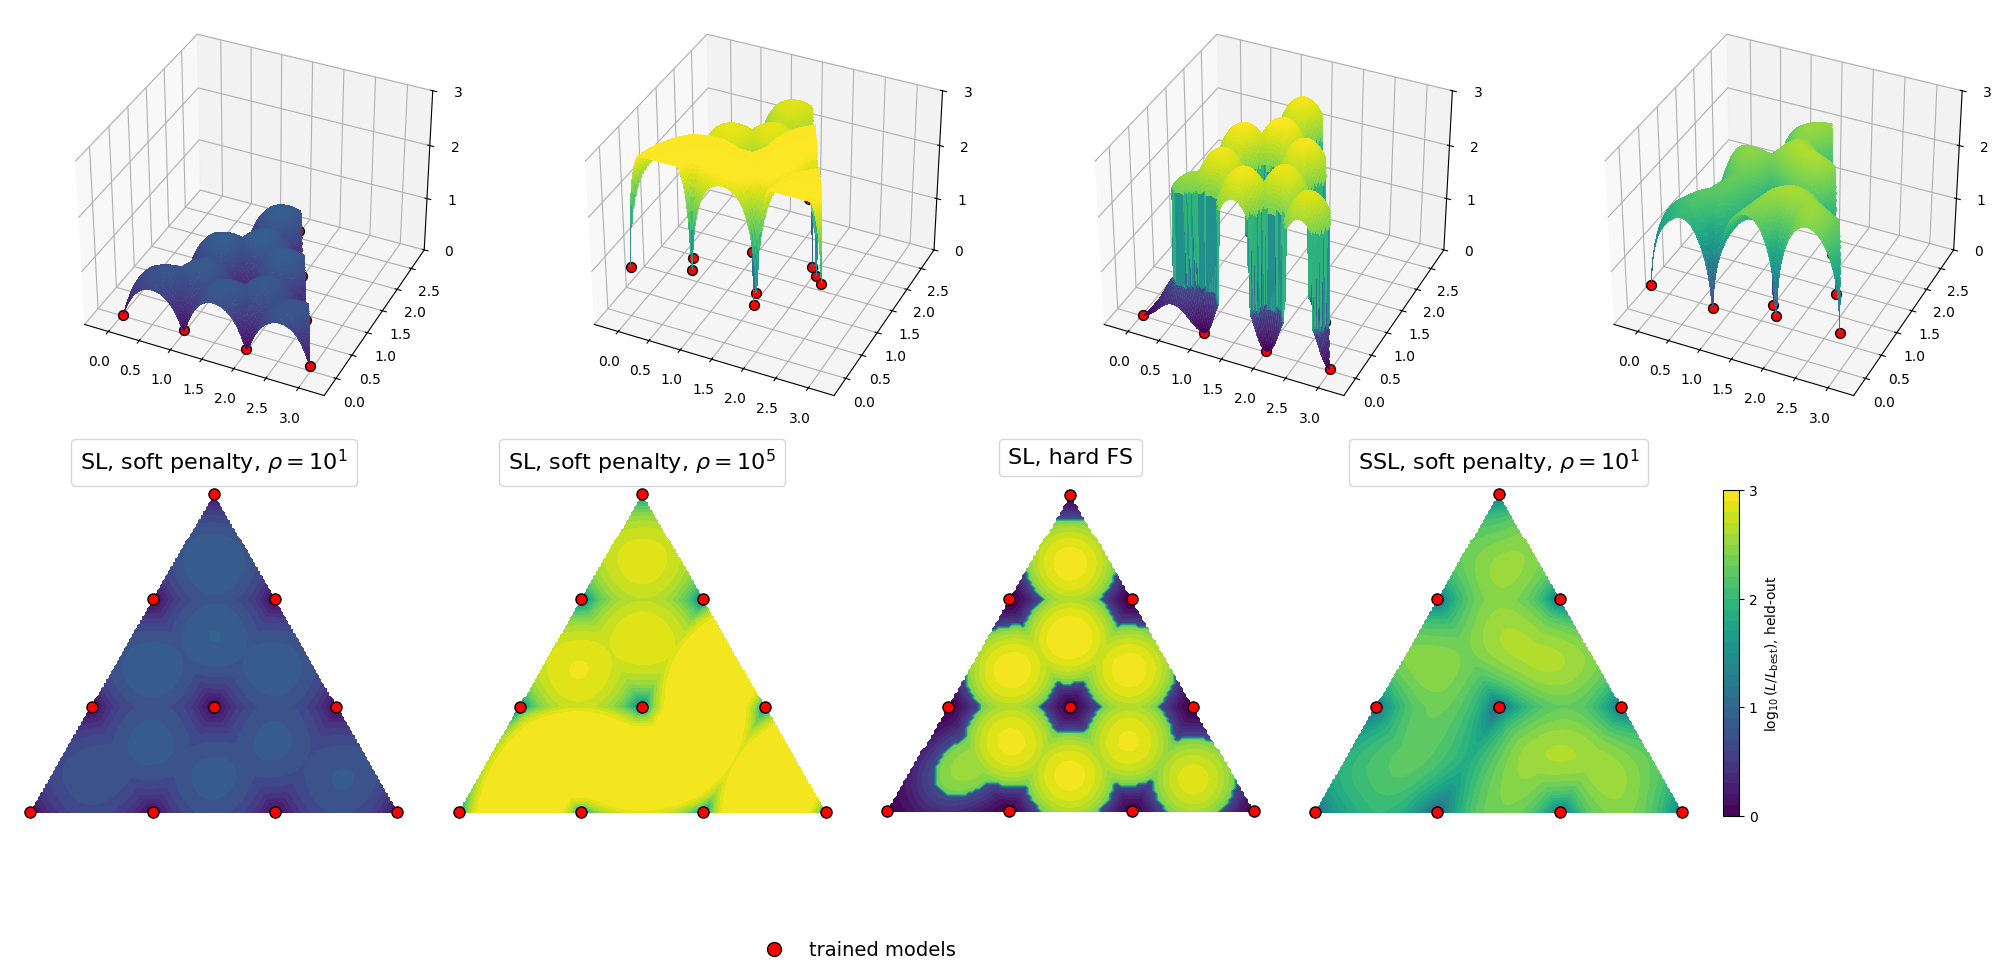

In [ ]:
# Current main figure: 10-seed flat sheet, no minima markers, smooth shading
figure([("straight", "3d", "own"), ("straight", "2d", "own")], METHODS,
       style=dict(minima=False, mesh=False, elev=35, stride=1))

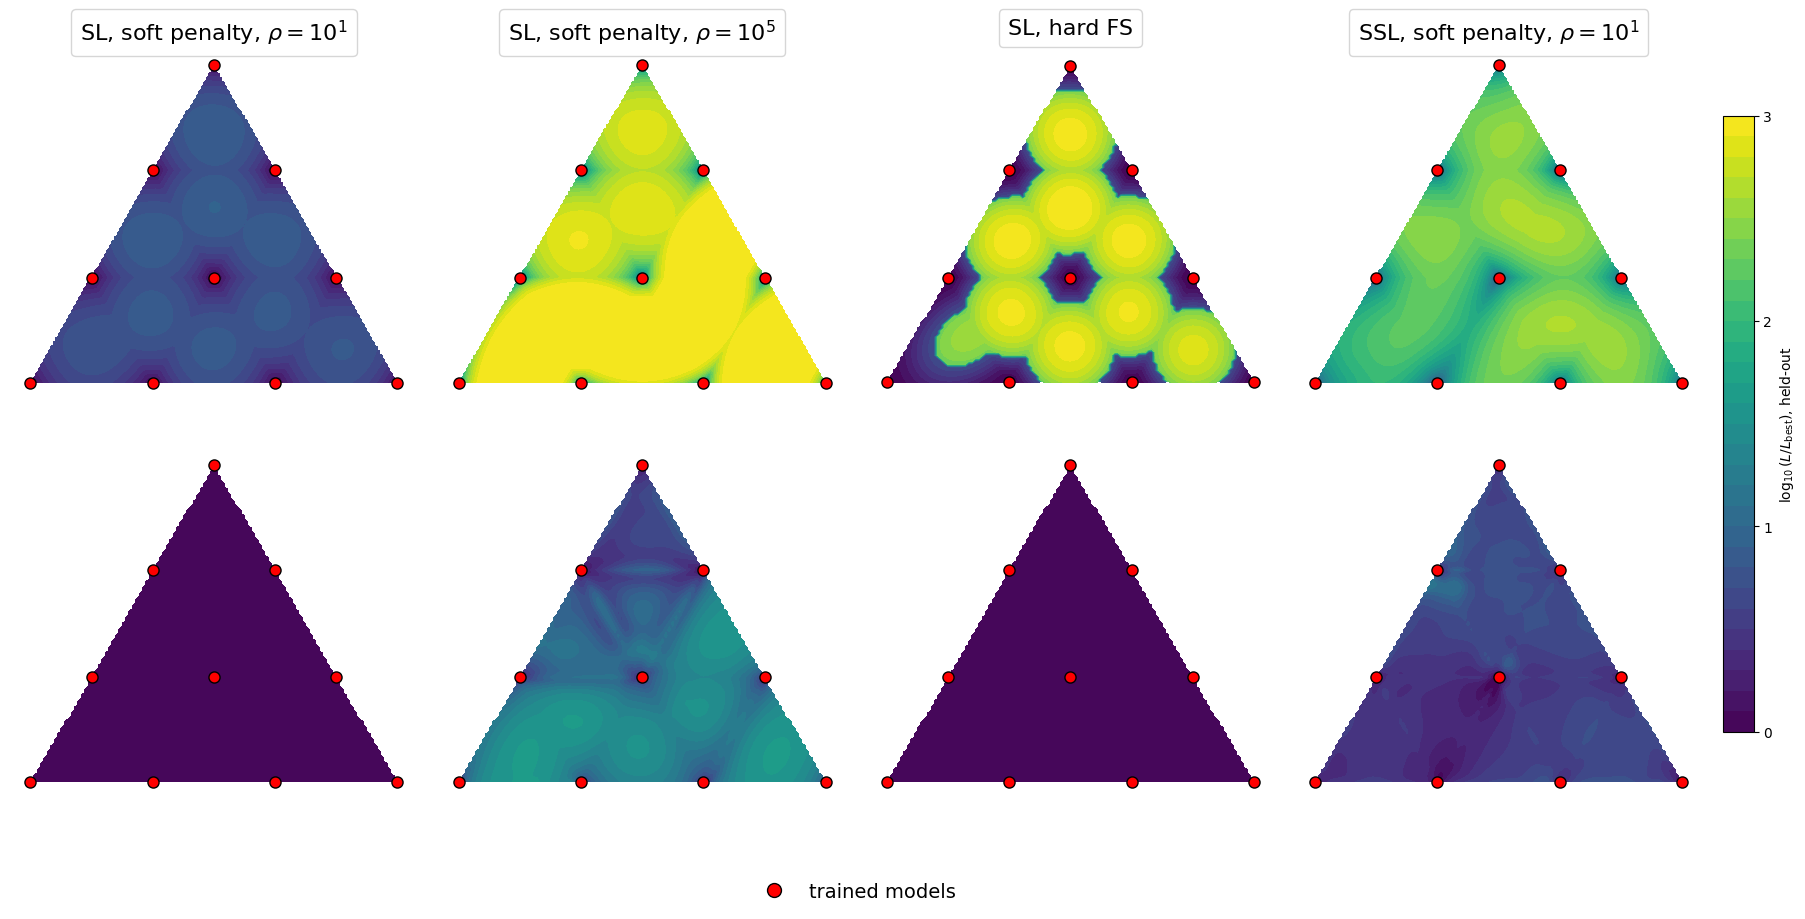

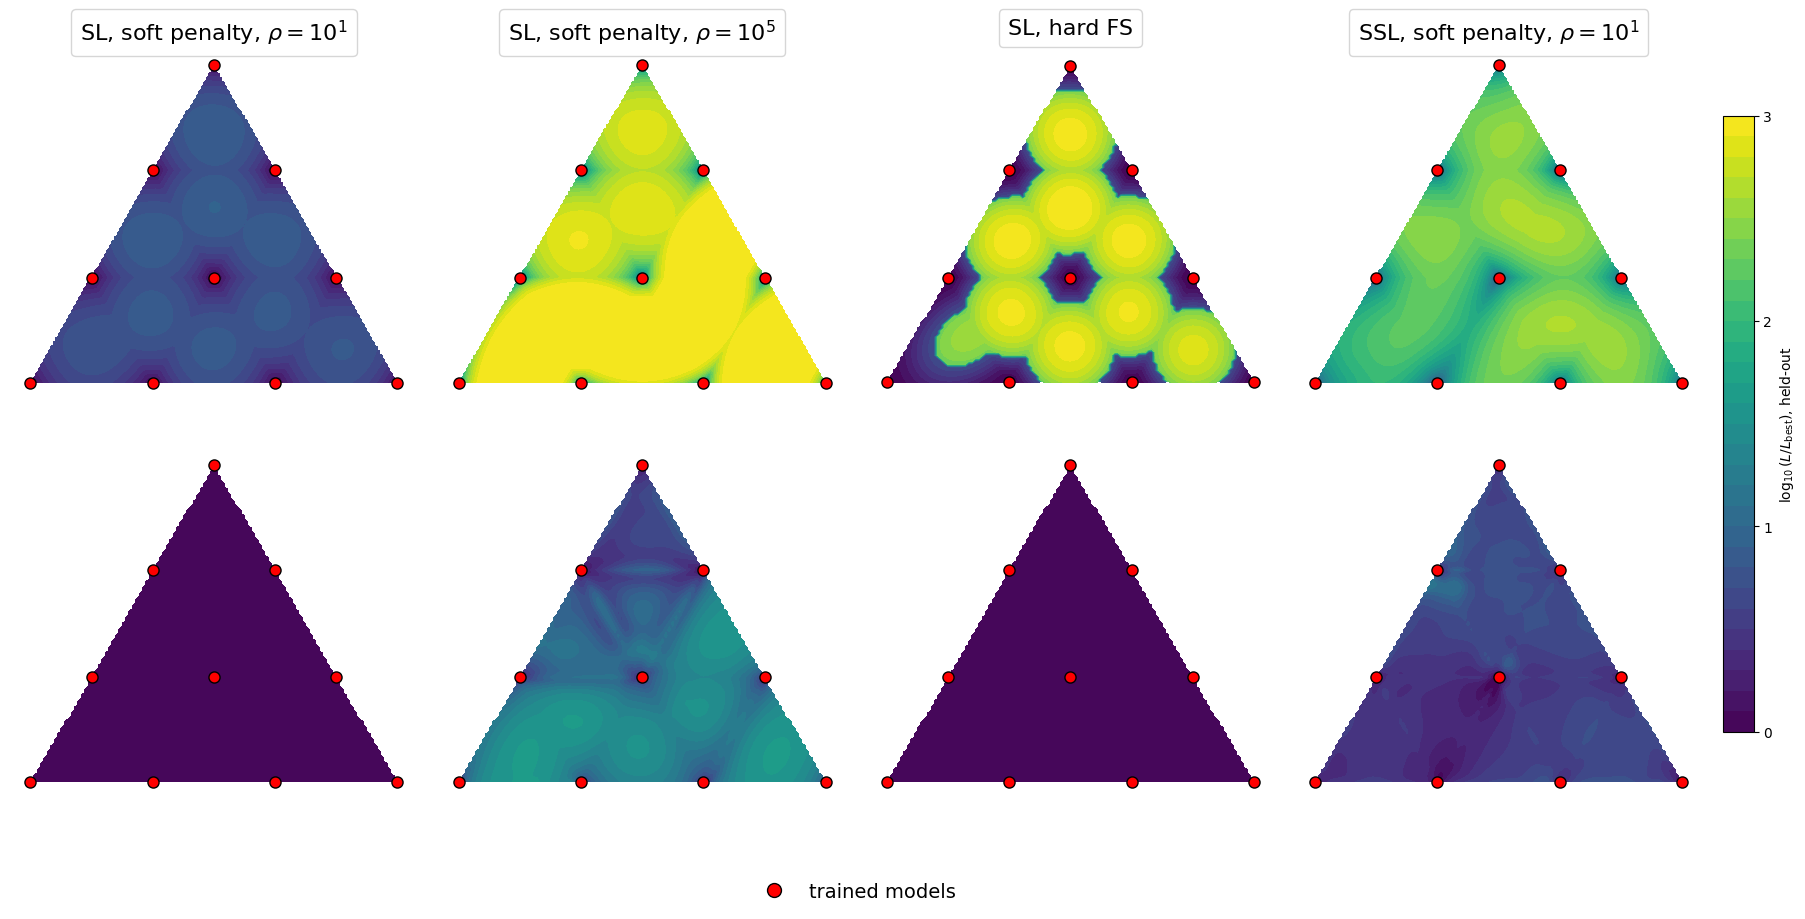

In [ ]:
# Straight vs curved sheet (2D only)
figure([("straight", "2d", "own"), ("curved", "2d", "own")], METHODS, style=dict(minima=False), row_h=5)

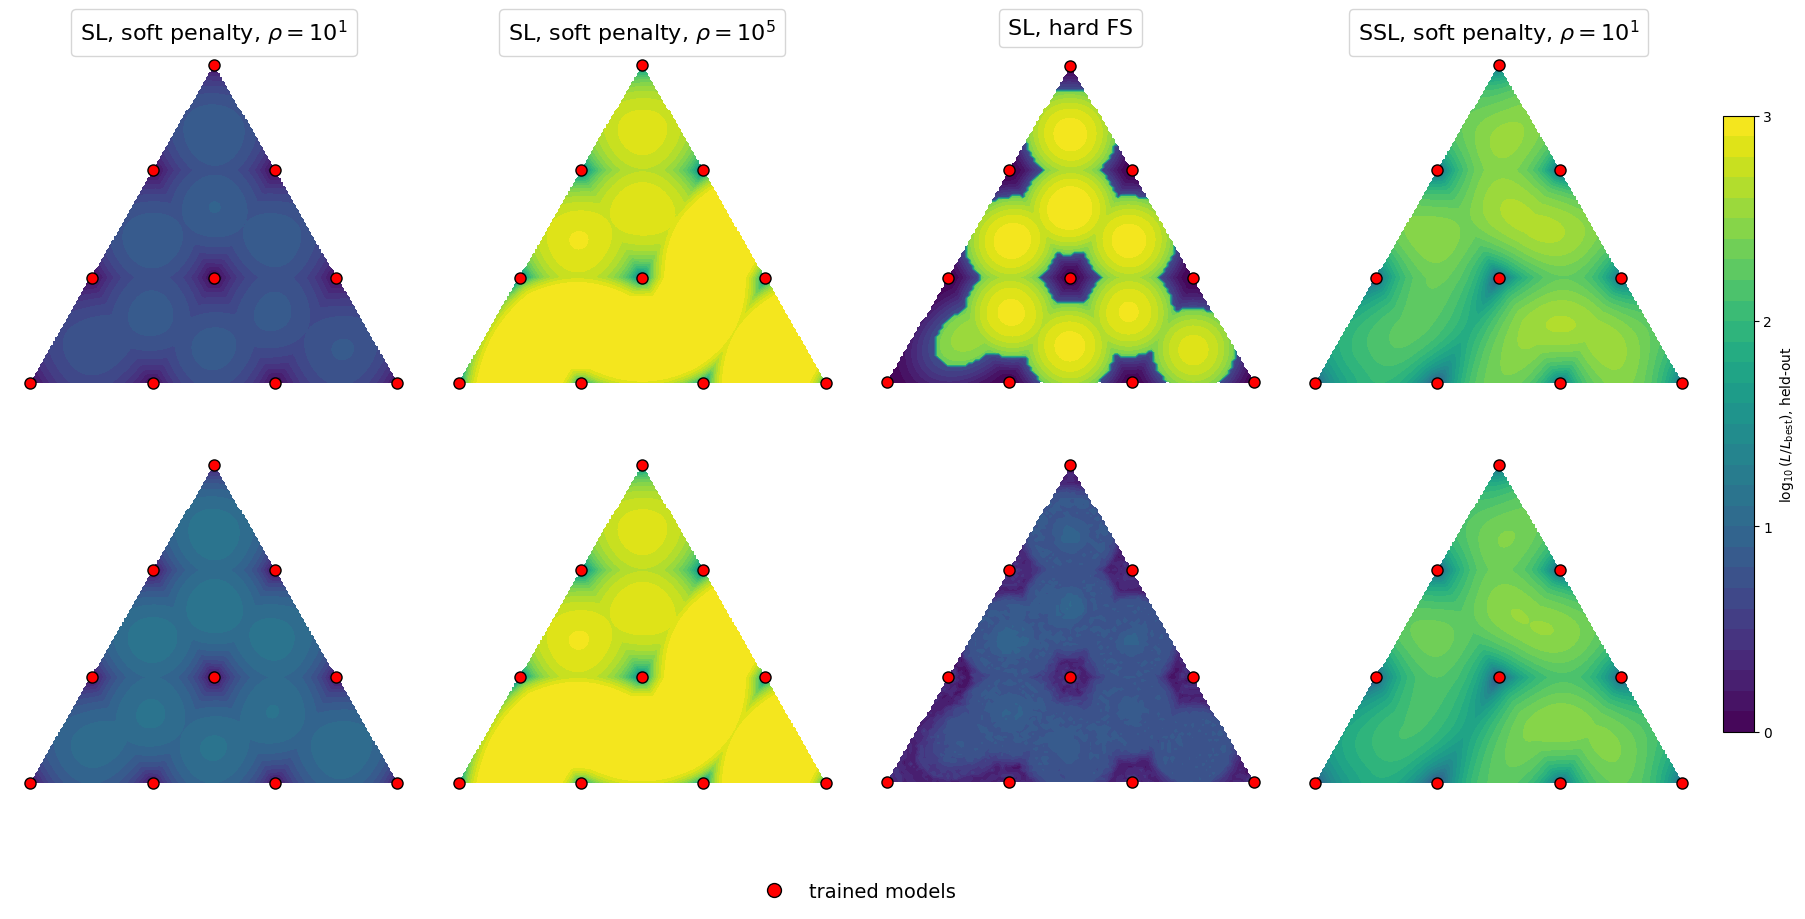

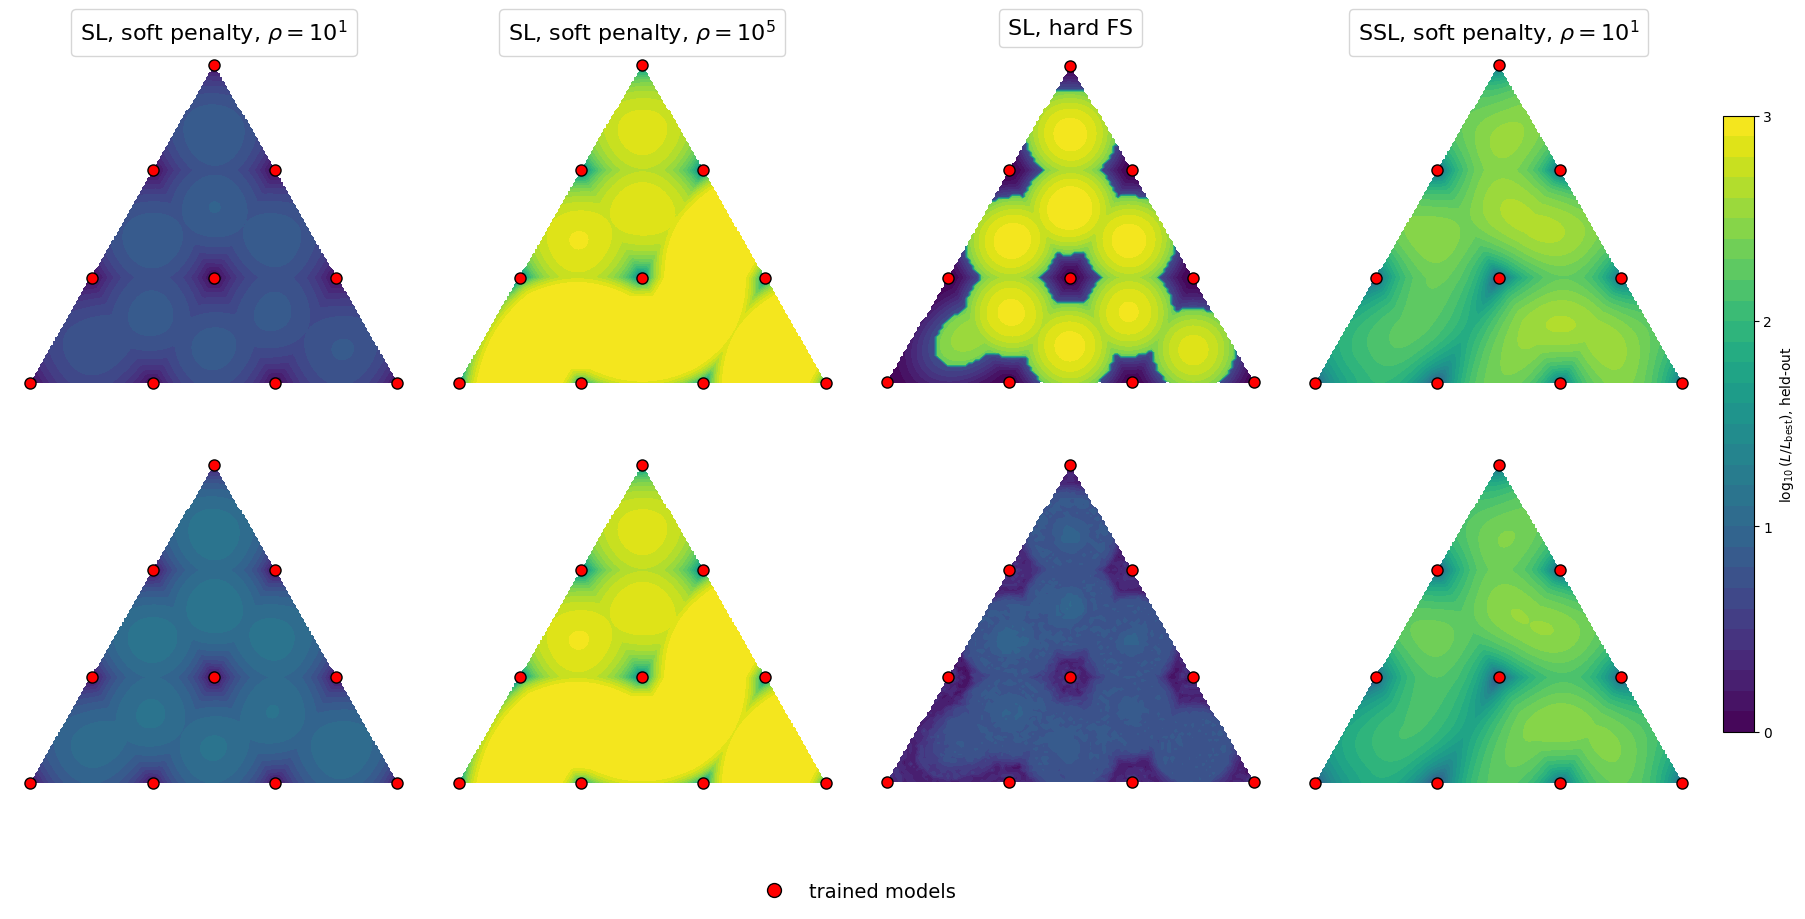

In [ ]:
# Objective mismatch: training loss vs merit on the same straight sheet
figure([("straight", "2d", "own"), ("straight", "2d", "merit")], METHODS, style=dict(minima=False), row_h=5)